In [2]:
import numpy as np
import random
import matplotlib.pyplot as plt
import cv2

(4000, 6000, 3)


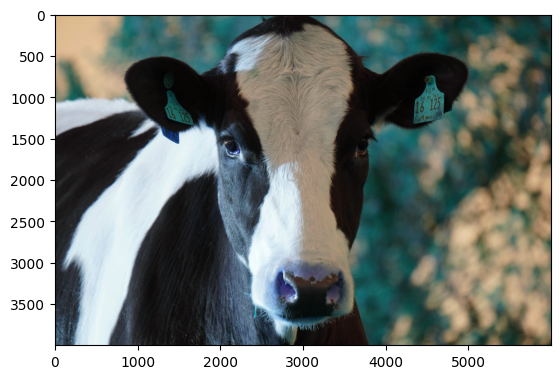

In [3]:
img = cv2.imread('pexels-gammel-23940471.jpg')
print(img.shape)
plt.imshow(img)

(512, 512, 3)


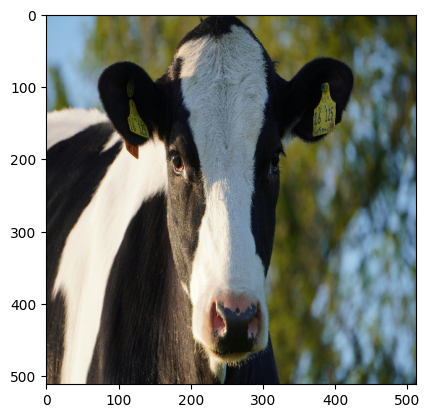

In [4]:
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (512,512))
print(img.shape)
plt.imshow(img)

In [5]:
# claculating ROI using Selective search
ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
ss.setBaseImage(img)
ss.switchToSelectiveSearchQuality()
rects = ss.process()
print('Total Regions generated', len(rects)) 

Total Regions generated 6179


In [6]:
for i in range(0,len(rects),100):
    output = img.copy()
    for (x,y,w,h) in rects[i:i+100]:
        color = [random.randint(0,255) for j in range(3)]
        cv2.rectangle(output, (x,y), (x+w, y+h), tuple(color), 2)
    cv2.imshow('Output', output)
    key = cv2.waitKey(0)
    if key == 27:  # ESC key
        break
cv2.destroyAllWindows()